In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer, make_column_selector
import os
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
hr = pd.read_csv(r"/home/sarthakredasani/Documents/CDAC_ML/Cases/Cases/human-resources-analytics/HR_comma_sep.csv")
X, y = hr.drop('left', axis=1), hr['left']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=25, test_size=0.3)

In [4]:
ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')
ct = make_column_transformer((ohe, make_column_selector(dtype_include=object)), 
                             ("passthrough",make_column_selector(dtype_exclude=object)),
                              verbose_feature_names_out=False)
ct = ct.set_output(transform='pandas')

In [5]:
X_trn_ohe = ct.fit_transform(X_train)
X_tst_ohe = ct.transform(X_test)

In [6]:
# Hyper-Parameter Tuning

In [7]:
depths = [2,3,4,5,6, None]
min_samples = [2, 20, 100, 500, 1000]
min_leaf = [1, 20, 50, 100, 500]
scores = []
for d in depths:
    for m in min_samples:
        for f in min_leaf:
                dtc = DecisionTreeClassifier(random_state=25, 
                        min_samples_leaf=f, max_depth=d, min_samples_split=m)
                dtc.fit(X_trn_ohe, y_train)
                y_pred = dtc.predict(X_tst_ohe)
                scores.append([d,m,f, accuracy_score(y_test, y_pred)])
df_scores = pd.DataFrame(scores, columns = ['Depth','Min Samples Split','Min Samples Leaf','score'])
df_scores.sort_values('score', ascending=False).iloc[0]

Depth                       NaN
Min Samples Split    100.000000
Min Samples Leaf       1.000000
score                  0.981551
Name: 135, dtype: float64

In [8]:
best_tree = DecisionTreeClassifier(random_state=25, 
                                   min_samples_leaf=1, max_depth=None, min_samples_split=100)
X_ohe = ct.fit_transform(X)
best_tree.fit(X_ohe,y)

DecisionTreeClassifier(min_samples_split=100, random_state=25)

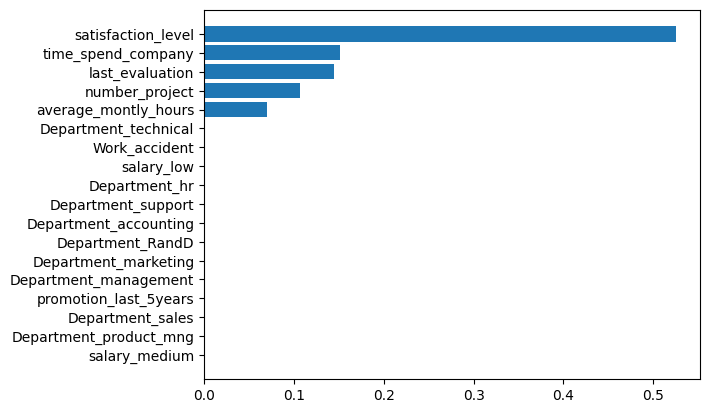

In [9]:
df_imp = pd.DataFrame({'Feature':list(X_ohe.columns),
                       'Importance':list(best_tree.feature_importances_)})
df_imp = df_imp.sort_values('Importance')
plt.barh(df_imp['Feature'], df_imp['Importance'])
plt.show()

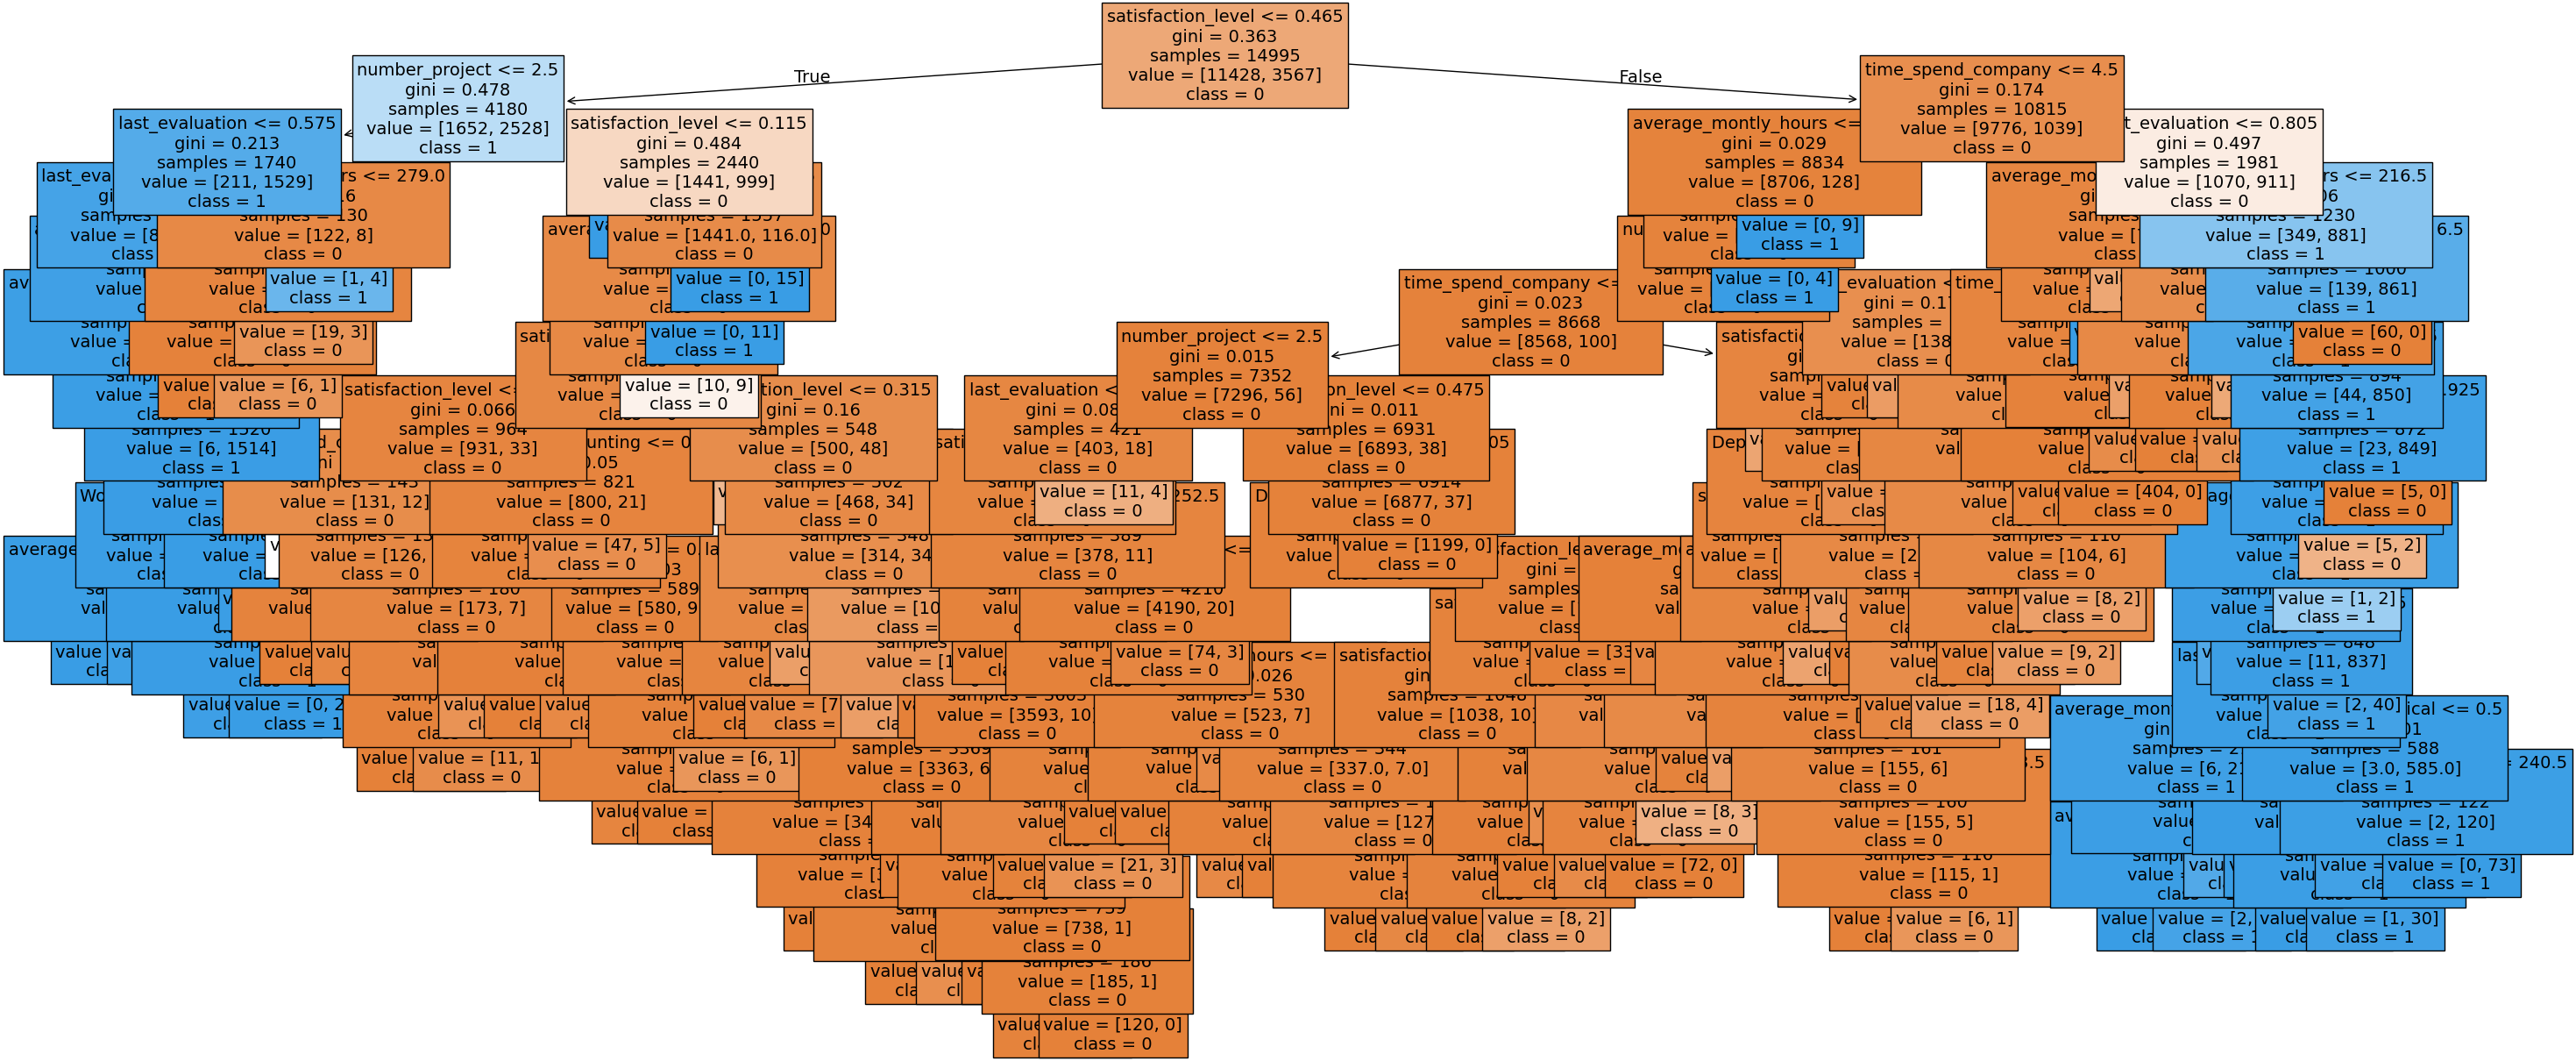

In [10]:
plt.figure(figsize=(35,15))
plot_tree(best_tree,feature_names=list(X_ohe.columns), 
          class_names=['0','1'], filled=True,fontsize=14)
plt.show() 